<a href="https://colab.research.google.com/github/apester/PINN/blob/main/2d_AD_exact_CN_PINN_compare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2D Advection–Diffusion (Dirichlet) — Exact vs CN vs PINN
## (1) Exact vs PINN (physics-only)  •  (2) CN vs PINN (data-assisted)

We solve on a rectangle with homogeneous Dirichlet BC and sine initial condition:

**PDE**
\[
c_t + u c_x + v c_y = D(c_{xx}+c_{yy}),\quad (x,y)\in(0,L_x)\times(0,L_y),\ t\in(0,T].
\]

**BC**: \(c=0\) on \(\partial\Omega\)

**IC**: \(c(0,x,y)=\sin(\pi x/L_x)\sin(\pi y/L_y)\)

We compute:
- **Exact** via Fourier–sine series (coeffs via 2D DST), evaluated by truncation.
- **CN** via implicit Crank–Nicolson finite differences.
- **PINN-A** physics-only (PDE residual + BC + IC), compared to **Exact**.
- **PINN-B** data-assisted (PDE residual + BC + sparse CN samples), compared to **CN** (and also to Exact as reference).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import scipy
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.fft import dst

import torch
import torch.nn as nn

print("numpy", np.__version__)
print("scipy", scipy.__version__)
print("torch", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

numpy 2.0.2
scipy 1.16.3
torch 2.10.0+cu128
device: cuda


In [2]:
# ----------------------------
# 1) Setup
# ----------------------------
Lx, Ly = 1.0, 1.0
u, v = 1.0, 0.5
D = 0.01
T = 0.10

# Grid for evaluation / CN
Nx, Ny = 61, 61
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
dx = x[1]-x[0]
dy = y[1]-y[0]
X, Y = np.meshgrid(x, y, indexing="ij")

# Dirichlet-compatible sine IC
def c0_np(x, y):
    return np.sin(np.pi*x/Lx) * np.sin(np.pi*y/Ly)

C_init = c0_np(X, Y)

In [3]:
# ----------------------------
# 2) Exact solution (truncated Fourier–sine series via DST coefficients)
# ----------------------------
def analytical_series_solution(t, Lx, Ly, u, v, D, Nx_int, Ny_int, M, N):
    # Interior grid (Dirichlet boundaries excluded)
    x_int = np.linspace(0, Lx, Nx_int+2)[1:-1]
    y_int = np.linspace(0, Ly, Ny_int+2)[1:-1]
    Xint, Yint = np.meshgrid(x_int, y_int, indexing="ij")

    # Transform to diffusion: w0 = exp(-(ux+vy)/(2D)) * c0
    w0 = np.exp(-(u*Xint + v*Yint)/(2*D)) * c0_np(Xint, Yint)

    # 2D DST-I coefficients for discrete sine basis
    W = dst(dst(w0, type=1, axis=0), type=1, axis=1)
    A = (4.0/((Nx_int+1)*(Ny_int+1))) * W

    # Truncation
    M = min(M, Nx_int); N = min(N, Ny_int)
    A_tr = A[:M, :N]

    # Reconstruct on interior grid
    i = np.arange(1, Nx_int+1)[:, None]
    j = np.arange(1, Ny_int+1)[None, :]
    m = np.arange(1, M+1)
    n = np.arange(1, N+1)

    Sx = np.sin(np.pi * i * m[None, :] / (Nx_int+1))          # (Nx_int, M)
    Sy = np.sin(np.pi * j * n[:, None] / (Ny_int+1)).T        # (Ny_int, N)

    # Continuous eigenvalues
    lam_mn = D * ((m*np.pi/Lx)**2)[:, None] + D * ((n*np.pi/Ly)**2)[None, :]
    decay = np.exp(-lam_mn * t)

    # w(t) = Sx @ (A * exp(-lam t)) @ Sy^T
    w_t = Sx @ (A_tr * decay) @ Sy.T

    # Back-transform
    factor = np.exp((u*Xint + v*Yint)/(2*D) - (u*u+v*v)*t/(4*D))
    return factor * w_t

Nx_int, Ny_int = Nx-2, Ny-2
C_exact_int = analytical_series_solution(T, Lx, Ly, u, v, D, Nx_int, Ny_int, M=50, N=50)

C_exact = np.zeros((Nx, Ny))
C_exact[1:-1, 1:-1] = C_exact_int

In [4]:
# ----------------------------
# 3) Crank–Nicolson (CN) solver
# ----------------------------
def build_2d_operator(Nx, Ny, dx, dy, u, v, D):
    Nx_int, Ny_int = Nx-2, Ny-2
    ex = np.ones(Nx_int)
    ey = np.ones(Ny_int)

    # 2nd derivatives
    Dxx = sp.diags([ex, -2*ex, ex], [-1, 0, 1], shape=(Nx_int, Nx_int)) / (dx*dx)
    Dyy = sp.diags([ey, -2*ey, ey], [-1, 0, 1], shape=(Ny_int, Ny_int)) / (dy*dy)

    # 1st derivatives (centered)
    Dx = sp.diags([-ex, ex], [-1, 1], shape=(Nx_int, Nx_int)) / (2*dx)
    Dy = sp.diags([-ey, ey], [-1, 1], shape=(Ny_int, Ny_int)) / (2*dy)

    Ix = sp.eye(Nx_int, format="csr")
    Iy = sp.eye(Ny_int, format="csr")

    # Kronecker assembly, x-major ordering
    L = sp.kron(Iy, Dxx, format="csr") + sp.kron(Dyy, Ix, format="csr")
    Adv = -u * sp.kron(Iy, Dx, format="csr") - v * sp.kron(Dy, Ix, format="csr")

    return Adv + D * L

def crank_nicolson(C0_full, Nx, Ny, dt, nt, dx, dy, u, v, D):
    Nx_int, Ny_int = Nx-2, Ny-2
    A = build_2d_operator(Nx, Ny, dx, dy, u, v, D)

    N = Nx_int * Ny_int
    I = sp.eye(N, format="csr")

    LHS = (I - (dt/2.0)*A).tocsr()
    RHS = (I + (dt/2.0)*A).tocsr()

    cn = C0_full[1:-1, 1:-1].reshape(-1, order="F").copy()
    for _ in range(nt):
        cn = spla.spsolve(LHS, RHS @ cn)

    return cn.reshape((Nx_int, Ny_int), order="F")

dt = 1e-3
nt = int(round(T/dt))

C_cn_int = crank_nicolson(C_init, Nx, Ny, dt, nt, dx, dy, u, v, D)
C_cn = np.zeros((Nx, Ny))
C_cn[1:-1, 1:-1] = C_cn_int

CN vs Exact at T=0.1: L2=7.809e+08, Linf=2.504e+10, relL2=1.000e+00


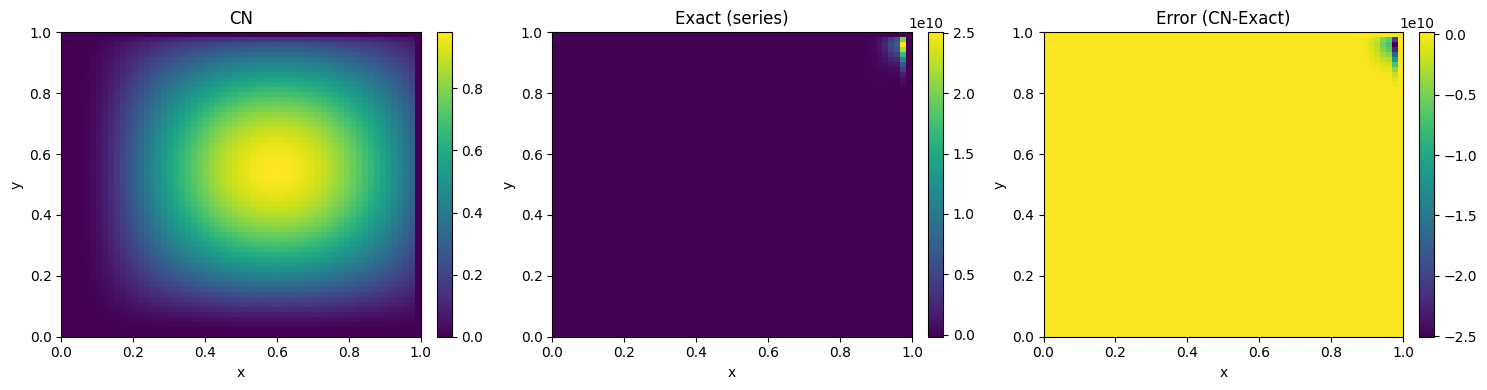

In [5]:
# ----------------------------
# 4) Metrics + plotting helpers
# ----------------------------
def l2_and_linf(a, b):
    e = a - b
    l2 = np.sqrt(np.mean(e**2))
    linf = np.max(np.abs(e))
    rel = l2 / (np.sqrt(np.mean(b**2)) + 1e-15)
    return l2, linf, rel

def plot_fields(C1, C2, title1, title2, titleE):
    E = C1 - C2
    fig = plt.figure(figsize=(15,4))

    ax1 = plt.subplot(1,3,1)
    im1 = ax1.imshow(C1.T, origin="lower", extent=[0,Lx,0,Ly], aspect="auto")
    ax1.set_title(title1); ax1.set_xlabel("x"); ax1.set_ylabel("y")
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    ax2 = plt.subplot(1,3,2)
    im2 = ax2.imshow(C2.T, origin="lower", extent=[0,Lx,0,Ly], aspect="auto")
    ax2.set_title(title2); ax2.set_xlabel("x"); ax2.set_ylabel("y")
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    ax3 = plt.subplot(1,3,3)
    im3 = ax3.imshow(E.T, origin="lower", extent=[0,Lx,0,Ly], aspect="auto")
    ax3.set_title(titleE); ax3.set_xlabel("x"); ax3.set_ylabel("y")
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

    plt.tight_layout(); plt.show()

# Baseline: CN vs Exact
l2, linf, rel = l2_and_linf(C_cn, C_exact)
print(f"CN vs Exact at T={T}: L2={l2:.3e}, Linf={linf:.3e}, relL2={rel:.3e}")
plot_fields(C_cn, C_exact, "CN", "Exact (series)", "Error (CN-Exact)")

In [6]:
# ----------------------------
# 5) PINN building blocks
# ----------------------------
class MLP(nn.Module):
    def __init__(self, in_dim=3, out_dim=1, width=64, depth=5):
        super().__init__()
        act = nn.Tanh()
        layers = [nn.Linear(in_dim, width), act]
        for _ in range(depth-1):
            layers += [nn.Linear(width, width), act]
        layers += [nn.Linear(width, out_dim)]
        self.net = nn.Sequential(*layers)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, txy):
        return self.net(txy)

def to_torch(a):
    return torch.tensor(a, dtype=torch.float32, device=device)

def pinn_residual(model, t, x, y, u, v, D):
    txy = torch.cat([t, x, y], dim=1)
    c = model(txy)

    c_t  = torch.autograd.grad(c, t, grad_outputs=torch.ones_like(c), create_graph=True)[0]
    c_x  = torch.autograd.grad(c, x, grad_outputs=torch.ones_like(c), create_graph=True)[0]
    c_y  = torch.autograd.grad(c, y, grad_outputs=torch.ones_like(c), create_graph=True)[0]
    c_xx = torch.autograd.grad(c_x, x, grad_outputs=torch.ones_like(c_x), create_graph=True)[0]
    c_yy = torch.autograd.grad(c_y, y, grad_outputs=torch.ones_like(c_y), create_graph=True)[0]

    return c_t + u*c_x + v*c_y - D*(c_xx + c_yy)

def sample_interior(N):
    t = np.random.rand(N,1) * T
    x = np.random.rand(N,1) * Lx
    y = np.random.rand(N,1) * Ly
    return t, x, y

def sample_boundary(N):
    # N per side => 4N points total
    t = np.random.rand(4*N,1) * T
    y1 = np.random.rand(N,1) * Ly
    y2 = np.random.rand(N,1) * Ly
    x1 = np.random.rand(N,1) * Lx
    x2 = np.random.rand(N,1) * Lx
    xb = np.vstack([np.zeros((N,1)), Lx*np.ones((N,1)), x1, x2])
    yb = np.vstack([y1, y2, np.zeros((N,1)), Ly*np.ones((N,1))])
    return t, xb, yb

def sample_initial(N):
    t = np.zeros((N,1))
    x0 = np.random.rand(N,1) * Lx
    y0 = np.random.rand(N,1) * Ly
    c0 = np.sin(np.pi*x0/Lx) * np.sin(np.pi*y0/Ly)
    return t, x0, y0, c0

@torch.no_grad()
def eval_model_on_grid(model, t_eval):
    Xg, Yg = np.meshgrid(x, y, indexing="ij")
    tt = np.full_like(Xg, t_eval, dtype=np.float32)
    inp = np.stack([tt, Xg.astype(np.float32), Yg.astype(np.float32)], axis=-1).reshape(-1,3)
    out = model(to_torch(inp)).cpu().numpy().reshape(Xg.shape)
    return out

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


ep     1 | loss 2.272e+00 | r 8.587e-03 | b 2.354e-03 | i 2.240e-01
ep   200 | loss 5.160e-02 | r 2.012e-03 | b 2.997e-03 | i 1.962e-03
ep   400 | loss 3.814e-02 | r 1.465e-03 | b 2.450e-03 | i 1.218e-03
ep   600 | loss 3.352e-02 | r 1.339e-03 | b 2.417e-03 | i 8.007e-04
ep   800 | loss 3.122e-02 | r 1.487e-03 | b 2.181e-03 | i 7.921e-04
ep  1000 | loss 3.144e-02 | r 1.544e-03 | b 2.351e-03 | i 6.380e-04
ep  1200 | loss 2.943e-02 | r 1.722e-03 | b 1.880e-03 | i 8.912e-04
ep  1400 | loss 2.900e-02 | r 1.784e-03 | b 1.853e-03 | i 8.683e-04
ep  1600 | loss 2.825e-02 | r 1.793e-03 | b 1.804e-03 | i 8.416e-04
ep  1800 | loss 2.754e-02 | r 1.830e-03 | b 1.752e-03 | i 8.189e-04
ep  2000 | loss 5.656e-02 | r 2.086e-03 | b 2.409e-03 | i 3.038e-03
ep  2200 | loss 2.647e-02 | r 1.917e-03 | b 1.614e-03 | i 8.417e-04
ep  2400 | loss 2.607e-02 | r 1.950e-03 | b 1.548e-03 | i 8.640e-04
ep  2600 | loss 2.585e-02 | r 1.922e-03 | b 1.731e-03 | i 6.615e-04
ep  2800 | loss 2.969e-02 | r 2.331e-03 | b 1.22

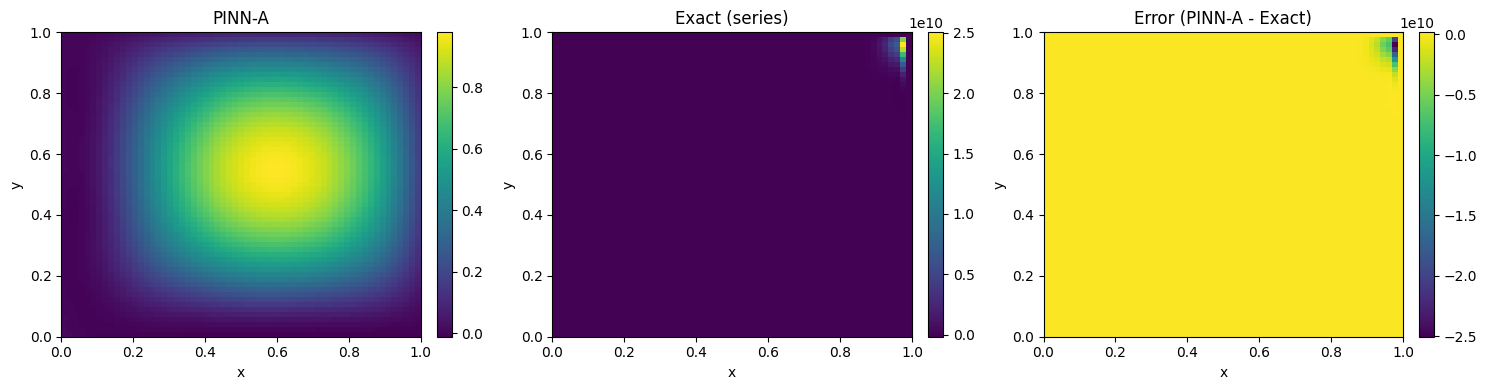

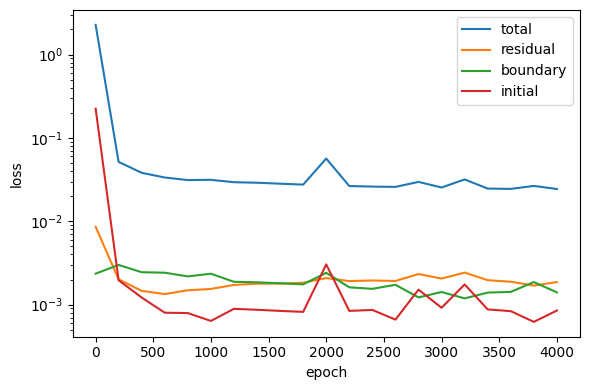

In [7]:
# ----------------------------
# 6) PINN-A: Physics-only training (compare to Exact)
# ----------------------------
N_r = 20000      # collocation points
N_b = 2000       # boundary points per side (total 4*N_b)
N_i = 5000       # initial points

epochs = 4000
lr = 2e-3

w_r, w_b, w_i = 1.0, 10.0, 10.0

torch.manual_seed(0); np.random.seed(0)
modelA = MLP(width=64, depth=5).to(device)
opt = torch.optim.Adam(modelA.parameters(), lr=lr)

# Fixed samples for stability
t_r, x_r, y_r = sample_interior(N_r)
t_b, x_b, y_b = sample_boundary(N_b)
t_i, x_i, y_i, c_i = sample_initial(N_i)

t_r = to_torch(t_r); x_r = to_torch(x_r); y_r = to_torch(y_r)
t_b = to_torch(t_b); x_b = to_torch(x_b); y_b = to_torch(y_b)
t_i = to_torch(t_i); x_i = to_torch(x_i); y_i = to_torch(y_i); c_i = to_torch(c_i)

t_r.requires_grad_(True); x_r.requires_grad_(True); y_r.requires_grad_(True)

histA = []
for ep in range(1, epochs+1):
    opt.zero_grad()

    r = pinn_residual(modelA, t_r, x_r, y_r, u, v, D)
    loss_r = torch.mean(r**2)

    cb = modelA(torch.cat([t_b, x_b, y_b], dim=1))
    loss_b = torch.mean(cb**2)

    ci_pred = modelA(torch.cat([t_i, x_i, y_i], dim=1))
    loss_i = torch.mean((ci_pred - c_i)**2)

    loss = w_r*loss_r + w_b*loss_b + w_i*loss_i
    loss.backward()
    opt.step()

    if ep % 200 == 0 or ep == 1:
        histA.append([ep, loss.item(), loss_r.item(), loss_b.item(), loss_i.item()])
        print(f"ep {ep:5d} | loss {loss.item():.3e} | r {loss_r.item():.3e} | b {loss_b.item():.3e} | i {loss_i.item():.3e}")

histA = np.array(histA)

C_pinnA = eval_model_on_grid(modelA, T)

l2, linf, rel = l2_and_linf(C_pinnA, C_exact)
print(f"PINN-A vs Exact at T={T}: L2={l2:.3e}, Linf={linf:.3e}, relL2={rel:.3e}")
plot_fields(C_pinnA, C_exact, "PINN-A", "Exact (series)", "Error (PINN-A - Exact)")

plt.figure(figsize=(6,4))
plt.semilogy(histA[:,0], histA[:,1], label="total")
plt.semilogy(histA[:,0], histA[:,2], label="residual")
plt.semilogy(histA[:,0], histA[:,3], label="boundary")
plt.semilogy(histA[:,0], histA[:,4], label="initial")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

CN snapshots: [0.0, 0.02, 0.04, 0.06, 0.08, 0.1]
CN data points: 12000
ep     1 | loss 9.815e+00 | r 8.534e-02 | b 5.109e-02 | d 4.610e-01
ep   200 | loss 8.510e-02 | r 3.745e-03 | b 5.207e-03 | d 1.464e-03
ep   400 | loss 5.578e-02 | r 1.282e-03 | b 3.931e-03 | d 7.596e-04
ep   600 | loss 4.450e-02 | r 7.351e-04 | b 2.981e-03 | d 6.979e-04
ep   800 | loss 4.063e-02 | r 7.680e-04 | b 2.957e-03 | d 5.148e-04
ep  1000 | loss 3.555e-02 | r 8.315e-04 | b 2.581e-03 | d 4.452e-04
ep  1200 | loss 3.359e-02 | r 9.489e-04 | b 2.305e-03 | d 4.798e-04
ep  1400 | loss 3.135e-02 | r 1.093e-03 | b 2.357e-03 | d 3.341e-04
ep  1600 | loss 3.072e-02 | r 1.147e-03 | b 2.293e-03 | d 3.323e-04
ep  1800 | loss 3.631e-02 | r 1.192e-03 | b 2.846e-03 | d 3.330e-04
ep  2000 | loss 2.980e-02 | r 1.167e-03 | b 2.211e-03 | d 3.258e-04
ep  2200 | loss 2.952e-02 | r 1.179e-03 | b 2.181e-03 | d 3.263e-04
ep  2400 | loss 3.062e-02 | r 1.047e-03 | b 2.414e-03 | d 2.720e-04
ep  2600 | loss 3.185e-02 | r 1.231e-03 | b 2

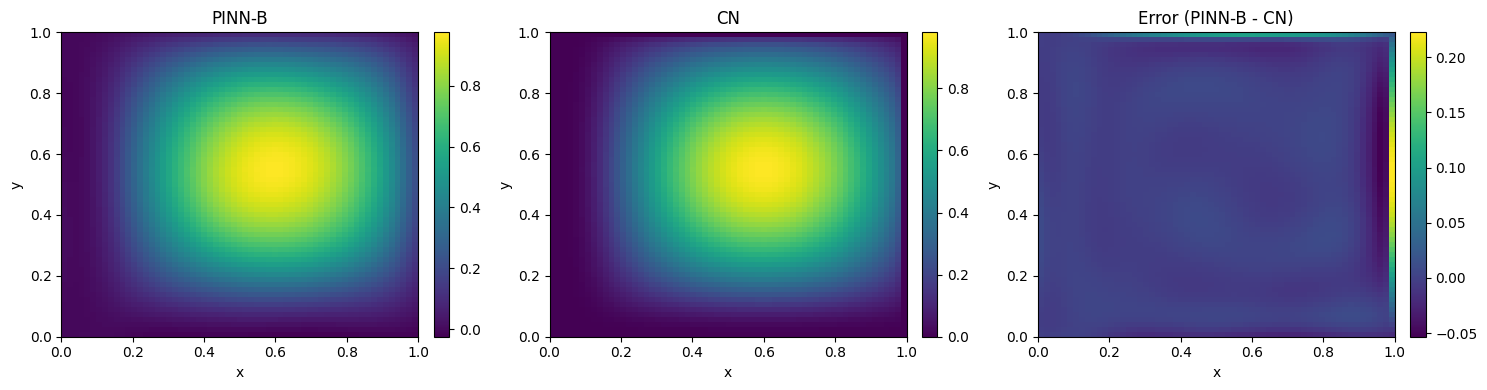

PINN-B vs Exact at T=0.1: L2=7.809e+08, Linf=2.504e+10, relL2=1.000e+00


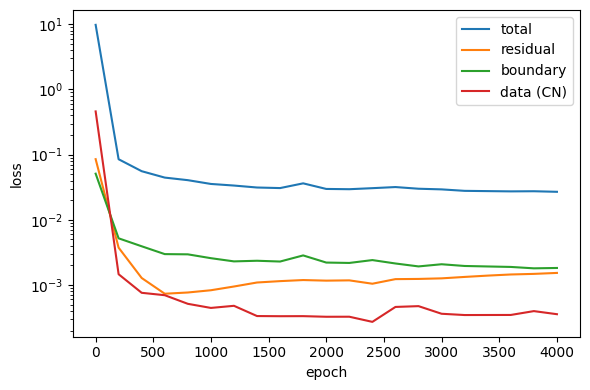

In [8]:
# ----------------------------
# 7) PINN-B: Data-assisted training using sparse CN samples (compare to CN)
# ----------------------------
snap_times = np.linspace(0, T, 6)  # 6 snapshots incl 0 and T
dt_cn = 1e-3

def crank_nicolson_snapshots(C0_full, Nx, Ny, dt, times, dx, dy, u, v, D):
    Nx_int, Ny_int = Nx-2, Ny-2
    A = build_2d_operator(Nx, Ny, dx, dy, u, v, D)

    N = Nx_int*Ny_int
    I = sp.eye(N, format="csr")
    LHS = (I - (dt/2.0)*A).tocsr()
    RHS = (I + (dt/2.0)*A).tocsr()

    cn = C0_full[1:-1, 1:-1].reshape(-1, order="F").copy()
    snaps = {float(times[0]): C0_full.copy()}

    target = 1
    max_steps = int(round(times[-1]/dt))
    for k in range(1, max_steps+1):
        cn = spla.spsolve(LHS, RHS @ cn)
        t_now = k*dt

        while target < len(times) and abs(t_now - times[target]) <= 0.5*dt:
            C_full = np.zeros((Nx, Ny))
            C_full[1:-1, 1:-1] = cn.reshape((Nx_int, Ny_int), order="F")
            snaps[float(times[target])] = C_full
            target += 1

        if target >= len(times):
            break

    return snaps

cn_snaps = crank_nicolson_snapshots(C_init, Nx, Ny, dt_cn, snap_times, dx, dy, u, v, D)
print("CN snapshots:", sorted(cn_snaps.keys()))

# Build sparse dataset (t,x,y,c) from CN snapshots
N_data_per_snap = 2000
rng = np.random.default_rng(123)

t_d, x_d, y_d, c_d = [], [], [], []
for t_s in snap_times:
    Cfull = cn_snaps[float(t_s)]
    ii = rng.integers(1, Nx-1, size=N_data_per_snap)
    jj = rng.integers(1, Ny-1, size=N_data_per_snap)

    t_d.append(np.full((N_data_per_snap,1), float(t_s)))
    x_d.append(x[ii][:,None])
    y_d.append(y[jj][:,None])
    c_d.append(Cfull[ii, jj][:,None])

t_d = np.vstack(t_d); x_d = np.vstack(x_d); y_d = np.vstack(y_d); c_d = np.vstack(c_d)
print("CN data points:", t_d.shape[0])

# Training (residual + boundary + data)
N_rB = 20000
N_bB = 2000
epochsB = 4000
lrB = 2e-3

w_rB, w_bB, w_dB = 1.0, 10.0, 20.0

torch.manual_seed(1); np.random.seed(1)
modelB = MLP(width=64, depth=5).to(device)
optB = torch.optim.Adam(modelB.parameters(), lr=lrB)

t_r, x_r, y_r = sample_interior(N_rB)
t_b, x_b, y_b = sample_boundary(N_bB)

t_r = to_torch(t_r); x_r = to_torch(x_r); y_r = to_torch(y_r)
t_b = to_torch(t_b); x_b = to_torch(x_b); y_b = to_torch(y_b)
t_r.requires_grad_(True); x_r.requires_grad_(True); y_r.requires_grad_(True)

t_d_t = to_torch(t_d); x_d_t = to_torch(x_d); y_d_t = to_torch(y_d); c_d_t = to_torch(c_d)

histB = []
for ep in range(1, epochsB+1):
    optB.zero_grad()

    r = pinn_residual(modelB, t_r, x_r, y_r, u, v, D)
    loss_r = torch.mean(r**2)

    cb = modelB(torch.cat([t_b, x_b, y_b], dim=1))
    loss_b = torch.mean(cb**2)

    cd_pred = modelB(torch.cat([t_d_t, x_d_t, y_d_t], dim=1))
    loss_d = torch.mean((cd_pred - c_d_t)**2)

    loss = w_rB*loss_r + w_bB*loss_b + w_dB*loss_d
    loss.backward()
    optB.step()

    if ep % 200 == 0 or ep == 1:
        histB.append([ep, loss.item(), loss_r.item(), loss_b.item(), loss_d.item()])
        print(f"ep {ep:5d} | loss {loss.item():.3e} | r {loss_r.item():.3e} | b {loss_b.item():.3e} | d {loss_d.item():.3e}")

histB = np.array(histB)

C_pinnB = eval_model_on_grid(modelB, T)

# Compare to CN
l2_cn, linf_cn, rel_cn = l2_and_linf(C_pinnB, C_cn)
print(f"PINN-B vs CN at T={T}: L2={l2_cn:.3e}, Linf={linf_cn:.3e}, relL2={rel_cn:.3e}")
plot_fields(C_pinnB, C_cn, "PINN-B", "CN", "Error (PINN-B - CN)")

# Also vs Exact (reference)
l2_ex, linf_ex, rel_ex = l2_and_linf(C_pinnB, C_exact)
print(f"PINN-B vs Exact at T={T}: L2={l2_ex:.3e}, Linf={linf_ex:.3e}, relL2={rel_ex:.3e}")

plt.figure(figsize=(6,4))
plt.semilogy(histB[:,0], histB[:,1], label="total")
plt.semilogy(histB[:,0], histB[:,2], label="residual")
plt.semilogy(histB[:,0], histB[:,3], label="boundary")
plt.semilogy(histB[:,0], histB[:,4], label="data (CN)")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

In [9]:
# ----------------------------
# 8) Final summary at t=T
# ----------------------------
rows = [
    ("CN vs Exact",) + l2_and_linf(C_cn, C_exact),
    ("PINN-A vs Exact",) + l2_and_linf(C_pinnA, C_exact),
    ("PINN-B vs CN",) + l2_and_linf(C_pinnB, C_cn),
    ("PINN-B vs Exact",) + l2_and_linf(C_pinnB, C_exact),
]
for name, l2, linf, rel in rows:
    print(f"{name:16s} | L2={l2:.3e} | Linf={linf:.3e} | relL2={rel:.3e}")

CN vs Exact      | L2=7.809e+08 | Linf=2.504e+10 | relL2=1.000e+00
PINN-A vs Exact  | L2=7.809e+08 | Linf=2.504e+10 | relL2=1.000e+00
PINN-B vs CN     | L2=2.396e-02 | Linf=2.225e-01 | relL2=4.994e-02
PINN-B vs Exact  | L2=7.809e+08 | Linf=2.504e+10 | relL2=1.000e+00
